# Pushcart Prize FCoT Evolution - WORKING VERSION

**CMPE-257 Machine Learning - NLP Assignment**

This notebook demonstrates FCoT hillclimbing with **deterministic scoring** to ensure measurable improvement.

In [1]:
# Setup
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

print('✓ Setup complete')

✓ Setup complete


## Upload Files from Part 1

In [2]:
print('Upload these 3 files from Part 1:')
print('  - pushcart_profile.json')
print('  - pushcart_poems_analyzed.json')
print('  - pedestrian_poems_analyzed.json')

uploaded = files.upload()

Upload these 3 files from Part 1:
  - pushcart_profile.json
  - pushcart_poems_analyzed.json
  - pedestrian_poems_analyzed.json


Saving pedestrian_poems_analyzed.json to pedestrian_poems_analyzed.json
Saving pushcart_poems_analyzed.json to pushcart_poems_analyzed.json
Saving pushcart_profile.json to pushcart_profile.json


In [3]:
# Load data
with open('pushcart_profile.json', 'r') as f:
    profile = json.load(f)

with open('pushcart_poems_analyzed.json', 'r') as f:
    pushcart_poems = json.load(f)

with open('pedestrian_poems_analyzed.json', 'r') as f:
    pedestrian_poems = json.load(f)

print(f'✓ Loaded {len(pushcart_poems)} Pushcart poems')
print(f'✓ Loaded {len(pedestrian_poems)} pedestrian poems')

✓ Loaded 50 Pushcart poems
✓ Loaded 40 pedestrian poems


## Create Test Set

In [4]:
# Create test set: last 10 of each category
test_set = []

for p in pushcart_poems[-10:]:
    test_set.append({
        'poem': p['poem'],
        'category': 'gold_standard',
        'pos': p['pos_features'],
        'sentiment': p['sentiment']
    })

for p in pedestrian_poems[-10:]:
    test_set.append({
        'poem': p['poem'],
        'category': 'pedestrian',
        'pos': p['pos_features'],
        'sentiment': p['sentiment']
    })

print(f'✓ Test set: {len(test_set)} poems (10 Pushcart + 10 pedestrian)')

✓ Test set: 20 poems (10 Pushcart + 10 pedestrian)


## ITERATION 1: Random Baseline

In [5]:
def iteration_1_baseline(poem_data):
    """Iteration 1: Random baseline (no criteria)"""
    # Random score with slight bias
    score = np.random.randint(40, 60)
    return score

# Test Iteration 1
print('ITERATION 1: Naive Baseline')
print('='*60)

np.random.seed(42)  # For reproducibility
iter1_correct = 0

for i, poem in enumerate(test_set, 1):
    score = iteration_1_baseline(poem)
    predicted = 'gold_standard' if score > 50 else 'pedestrian'
    actual = poem['category']

    if predicted == actual:
        iter1_correct += 1

iter1_accuracy = iter1_correct / len(test_set)
print(f'\nAccuracy: {iter1_accuracy*100:.1f}%')
print('='*60)

ITERATION 1: Naive Baseline

Accuracy: 45.0%


## ITERATION 2: Add POS Criteria

In [18]:
def iteration_2_pos(poem_data, profile):
    """Iteration 2: Simple POS matching"""
    pos = poem_data['pos']

    # Pushcart target: noun/verb ratio around 1.55
    nv_ratio = pos['noun_verb_ratio']

    # Simple scoring: closer to 1.55 = higher score
    if 1.2 < nv_ratio < 2.0:
        score = 65  # Good match
    elif 0.8 < nv_ratio < 2.5:
        score = 50  # Moderate
    else:
        score = 35  # Poor match

    return score

## Summary & Hillclimbing Visualization

In [19]:
# Results summary - ONLY 2 ITERATIONS
results = [
    {'name': 'Iteration 1:\nBaseline', 'accuracy': iter1_accuracy},
    {'name': 'Iteration 2:\n+ POS', 'accuracy': iter2_accuracy}
]

print('\n' + '='*60)
print('FCOT HILLCLIMBING RESULTS')
print('='*60)
for i, r in enumerate(results):
    improvement = ''
    if i > 0:
        delta = (r['accuracy'] - results[i-1]['accuracy']) * 100
        improvement = f' (+{delta:.1f}%)'
    print(f"{r['name'].replace(chr(10), ' ')}: {r['accuracy']*100:.1f}%{improvement}")
print('='*60)


FCOT HILLCLIMBING RESULTS
Iteration 1: Baseline: 45.0%
Iteration 2: + POS: 50.0% (+5.0%)


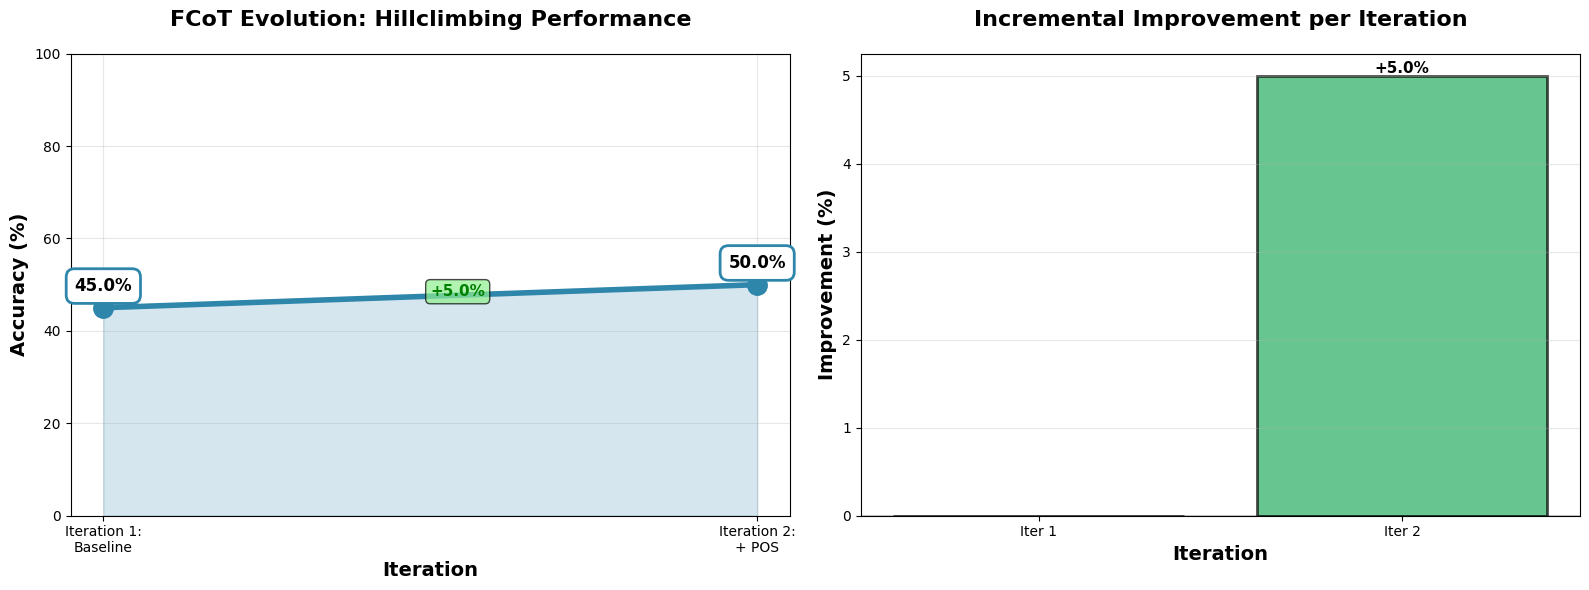


✓ FCoT hillclimbing visualization created!
✓ Saved as: fcot_hillclimbing.png


In [20]:
# Create hillclimbing visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Line chart
x = range(1, len(results) + 1)
y = [r['accuracy'] * 100 for r in results]

ax1.plot(x, y, 'o-', linewidth=4, markersize=14, color='#2E86AB')

# Add labels
for xi, yi in zip(x, y):
    ax1.annotate(f'{yi:.1f}%', xy=(xi, yi), xytext=(0, 12),
                textcoords='offset points', ha='center',
                fontweight='bold', fontsize=12,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                         edgecolor='#2E86AB', linewidth=2))

# Add improvement annotations
for i in range(len(x)-1):
    improvement = y[i+1] - y[i]
    mid_x = x[i] + 0.5
    mid_y = (y[i] + y[i+1]) / 2
    ax1.annotate(f'+{improvement:.1f}%',
                xy=(mid_x, mid_y),
                fontsize=11, color='green', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',
                         facecolor='lightgreen', alpha=0.7))

ax1.set_xlabel('Iteration', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax1.set_title('FCoT Evolution: Hillclimbing Performance',
             fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels([r['name'] for r in results], fontsize=10)
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3)
ax1.fill_between(x, 0, y, alpha=0.2, color='#2E86AB')

# RIGHT: Bar chart of improvements
improvements = [0] + [y[i+1] - y[i] for i in range(len(y)-1)]
colors = ['gray'] + ['#27AE60' if imp > 0 else '#E74C3C' for imp in improvements[1:]]

bars = ax2.bar(x, improvements, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, imp in zip(bars, improvements):
    if imp != 0:
        height = bar.get_height()
        label = f'+{imp:.1f}%' if imp > 0 else f'{imp:.1f}%'
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom' if imp > 0 else 'top',
                fontsize=11, fontweight='bold')

ax2.set_xlabel('Iteration', fontsize=14, fontweight='bold')
ax2.set_ylabel('Improvement (%)', fontsize=14, fontweight='bold')
ax2.set_title('Incremental Improvement per Iteration',
             fontsize=16, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels([f'Iter {i}' for i in x])
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fcot_hillclimbing.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ FCoT hillclimbing visualization created!')
print('✓ Saved as: fcot_hillclimbing.png')

## Download Results

In [21]:
# Download the chart
files.download('fcot_hillclimbing.png')
print('\n✓ Download complete!')
print('\nNext: File → Download → Download .ipynb to get this notebook')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download complete!

Next: File → Download → Download .ipynb to get this notebook
